In [1]:
import os
from typing import Annotated, TypedDict

from dotenv import load_dotenv

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


### State
- 그래프가 실행되는 동안 있는 단일 데이터 객체
- 각 Node는 State를 입력으로 받아 값을 추가/수정하고, 업데이트된 State가 다음 Node로 전달
- TypeDict를 상속받는 클래스
    - State 구조를 명시

In [2]:
from __future__ import annotations

from typing import Any, Dict, List, Literal, Optional
from typing_extensions import Annotated, NotRequired, TypedDict
from pydantic import BaseModel, Field

from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, RemoveMessage
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

import uuid

Route = Literal["direct", "rag", "web"]

# RAG
class RagDocument(TypedDict):
    doc_id: NotRequired[str]          
    text: str                         
    score: NotRequired[float]         
    source: NotRequired[str]        
    metadata: NotRequired[Dict[str, Any]]


# WebSearch
class WebResult(TypedDict):
    title: str
    url: str
    snippet: NotRequired[str]  
    score: NotRequired[float]        
    published_date: NotRequired[str]  


# Router
class RouterDecision(BaseModel):
    route: Literal["direct", "rag", "web"] = Field(description="다음 실행할 단계")
    route_reason: str = Field(description="선택한 이유")

# Citation
class Citation(TypedDict):
    kind: Literal["rag", "web"]
    title: NotRequired[str]         
    url: NotRequired[str]       
    source: NotRequired[str]        
    doc_id: NotRequired[str]        
    quote: NotRequired[str]    
    score: NotRequired[float]


# Debug
class NodeError(TypedDict):
    node: str
    message: str
    detail: NotRequired[Dict[str, Any]]


class State(TypedDict):
    messages: Annotated[List[AnyMessage], add_messages]
    summary: NotRequired[str]

    query: str
    user_info: NotRequired[Dict]

    # 라우팅 결정
    route: NotRequired[Route]
    route_reason: NotRequired[str] 

    # 검색 결과
    documents: NotRequired[List[RagDocument]]
    web_results: NotRequired[List[WebResult]]

    # 출력
    final_answer: NotRequired[str]
    citations: NotRequired[List[Citation]]

    # 운영/디버깅
    trace: NotRequired[List[str]]   
    errors: NotRequired[List[NodeError]]
    timings_ms: NotRequired[Dict[str, int]] 


### Node
- State를 입력으로 받아 State의 일부를 계산 및 갱신
- Graph의 업무 단위
- 동작 과정
    - 입력: State
    - 처리: 어떤 로직을 수행할지 결정
    - 출력: State의 부분 업데이트

In [3]:
### Router Node
def router_node(state: State):
    print("[Router]: 경로 탐색 중...")
    
    structured_llm = llm.with_structured_output(RouterDecision)
    question = state.get("query") or state["messages"][-1].content

    try:
        decision = structured_llm.invoke(question)
        route = decision.route
        reason = decision.route_reason
    except Exception as e:
        route = "rag"
        reason = f"Router fallback due to error: {type(e).__name__}"

    return {"route": route, "route_reason": reason}

# RAG Retrieve Node
def rag_node(state: State):
    print("[RAG]: 내부 문서 검색 중...")

    query = state.get("query") or state["messages"][-1].content
    docs = retriever.invoke(query)

    documents = []
    for d in docs:
        documents.append({
            "text": getattr(d, "page_content", str(d)),
            "metadata": getattr(d, "metadata", {}),
        })
    
    return {"documents": documents}

# WebSearch Node
def web_search_node(state: State):
    print("[Web]: 웹 검색 중...")

    query = state.get("query") or state["messages"][-1].content
    results = tavily.search(query=query, max_results=5)
    
    search_hits = results.get("results", []) if isinstance(results, dict) else results

    web_results = []
    for r in search_hits:
        web_results.append({
            "title": r.get("title", ""),
            "url": r.get("url", ""),
            "snippet": r.get("content") or r.get("snippet", ""),
        })

    return {"web_results": web_results}

# Answer Node
def chatbot_node(state: State):
    print("[Chatbot]: 최종 답변 생성  중...")
    
    messages = state["messages"]
    route = state.get("route", "direct")
    
    context = ""
    
    if route == "rag":
        docs = state.get("documents", [])
        context_text = "\n\n".join([d["text"] for d in docs])
        context = f"[참고 문서]\n{context_text}"
        
    elif route == "web":
        webs = state.get("web_results", [])
        web_text = "\n\n".join([f"{w['title']}: {w['snippet']}" for w in webs])
        context = f"[인터넷 검색 결과]\n{web_text}"
    

    system_prompt = f"""당신은 친절한 여행 가이드입니다.
사용자의 질문에 대해 아래 [정보]를 바탕으로 답변하세요.
정보가 없으면 아는 대로 답변하세요.

{context}
"""
    
    prompt_messages = [SystemMessage(content=system_prompt)] + messages
    
    response = llm.invoke(prompt_messages)
    
    return {
        "final_answer": response.content,
        "messages": [response] 
    }

def summarize_node(state: State):
    summary = state.get("summary", "")
    messages = state["messages"]

    if len(messages) > 6:
        prompt = f"""
        지금까지의 요약: {summary}
        새로운 대화:
        {messages}
        
        위 내용을 바탕으로 전체 대화 내용을 짧게 요약해줘.
        """

        response = llm.invoke(prompt)
        new_summary = response.content

        delete_messages = [RemoveMessage(id=m.id) for m in messages[:-2]]

        return {
                "summary": new_summary, 
                "messages": delete_messages # 삭제 명령
            }
        
    return {}
# 후처리..?

### Edge
1. Normal Edge
    - .add_edge
2. Conditional Edge
    - .add_conditional_edges

In [4]:
def get_next_step(state: State) -> Literal["rag", "web", "chatbot"]:
    route = state["route"]
    
    if route == "rag":
        return "rag"      # rag_node
    elif route == "web":
        return "web"      # web_search_node
    else:
        return "chatbot"  # direct인 경우

def should_summarize(state: State):
    if len(state["messages"]) > 6:
        return "summarize"
    return "end"

def build_graph(checkpointer=None) -> any:
    workflow = StateGraph(State)

    workflow.add_node("router", router_node)
    workflow.add_node("rag", rag_node)
    workflow.add_node("web", web_search_node)
    workflow.add_node("chatbot", chatbot_node)
    workflow.add_node("summarize", summarize_node)

    workflow.add_edge(START, "router")

    workflow.add_conditional_edges(
        "router",
        get_next_step,   
        {            
            "rag": "rag",
            "web": "web",
            "chatbot": "chatbot" 
        }
    )

    workflow.add_edge("rag", "chatbot")
    workflow.add_edge("web", "chatbot")

    workflow.add_conditional_edges(
        "chatbot",        
        should_summarize,    
        {
            "summarize": "summarize",
            "end": END               
        }
    )

    workflow.add_edge("summarize", END)

    return workflow.compile(checkpointer=checkpointer)

In [5]:
app = build_graph()

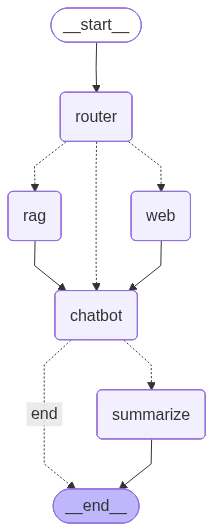

In [6]:
app

## 예시로 테스트 해보기

In [7]:
from langchain_tavily import TavilySearch
from langchain_core.documents import Document

load_dotenv()

llm = init_chat_model("openai:gpt-5-nano")

class MockRetriever:
    def invoke(self, query):
        print(f"[Mock RAG]'{query}'에 대한 검색 시늉을 합니다...")
        return [
            Document(page_content="이 문서는 테스트용 가짜 데이터입니다. RAG가 아직 연결되지 않았습니다.", metadata={"source": "test"})
        ]

retriever = MockRetriever()

try:
    tavily = TavilySearch(max_results=3)
except Exception:
    print("Tavily API 키가 없어서 웹 검색도 가짜(Mock)로 설정합니다.")
    class MockTavily:
        def search(self, query, max_results=5):
            return [{"title": "테스트 뉴스", "url": "http://test.com", "content": "웹 검색 결과 예시입니다."}]
    tavily = MockTavily()

app = build_graph()

Tavily API 키가 없어서 웹 검색도 가짜(Mock)로 설정합니다.


In [8]:
memory = MemorySaver()

app = build_graph(checkpointer=memory)

thread_id = "test_user_01"
config = {"configurable": {"thread_id": thread_id}}

print(f"[Test] 대화를 시작합니다! (ID: {thread_id})")
print("종료하려면 'q'를 입력하세요.\n" + "="*40)

[Test] 대화를 시작합니다! (ID: test_user_01)
종료하려면 'q'를 입력하세요.


In [9]:
while True:
    user_input = input("User: ")
    if user_input.lower() in ["q", "quit"]:
        print("종료합니다.")
        break
    
    inputs = {"messages": [HumanMessage(content=user_input)]}
    

    result = app.invoke(inputs, config=config)
    
    ai_msg = result["final_answer"]
    route = result.get("route", "알 수 없음")
    summary = result.get("summary", "")

    print(f"AI: {ai_msg}")
    print(f" └─ [Debug] 경로: {route}")
    
    if summary:
        print(f"   └─ [Debug] 📝 요약 발생: {summary}")
    
    print("-" * 40)

[Router]: 경로 탐색 중...
[Chatbot]: 최종 답변 생성  중...
AI: 반가워요, 세현님! 1박 2일로 부산 잘 즐길 수 있게 간단하고 알찬 코스를 하나 짜볼게요. 서울 출발로 KTX/SRT 이용하면 금방 도착하고, 해운대·광안리 주변은 루트로 편하고 맛집도 많습니다.

추천 교통수단
- KTX(서울역) 또는 SRT(수서) 이용: 서울에서 부산까지 보통 2.5~3시간대. 예매는 가능하면 미리 해두면 저렴하고 좌석도 편합니다.
- 도착 시 이동: 부산역·해운대역 근처로 먼저 이동하면 코스 관리가 편합니다. 지하철 2호선, 1호선, 광안대교 인근 편의시설 이용 가능.

무난한 1박 2일 루트(해운대/광안리 중심)
- Day 1
  - 아침 출발 → 부산 도착 후 해운대
  - 해운대 해수욕장 산책 + 동백섬 산책로
  - 점심: 해운대 근처 해물이나 밀면 추천
  - 오후: 광안리로 이동 → 광안대교 전망 카페나 해변 산책
  - 저녁: 남포동/자갈치 시장 근처에서 신선한 해산물이나 지역 식당 체험
  - 숙박: 해운대 or 광안리 근처 호텔/게스트하우스
  - 야간: 광안대교 야경 산책
- Day 2
  - 아침: 감천문화마을 벽화 골목 산책
  - 태종대 공원으로 이동(등대/바다 풍경 감상)
  - 점심: 태종대 인근 해물/칼국수 등 식사
  - 오후: 부산역 혹은 센텀·남포동으로 이동해 간단한 기념품 쇼핑
  - 늦은 오후: KTX/SRT로 서울 복귀

대안 코스 (문화+풍경 위주)
- Day 1: 감천문화마을 → 자갈치시장/BIFF 광장 → 남포동 쇼핑 or 광안리 카페
- Day 2: 태종대 또는 욱일산책로/대개로 코스 → 해운대 해수욕장 및 누리마루 APEC 하우스 구경
- 이쪽 루트는 벽화와 바다 풍경 위주로 느긋하게 다니기 좋습니다.

식사 팁
- 해운대: 밀면, 회센터, 해물탕
- 자갈치/남포동: 신선한 해산물 구이, 조개구이, 돼지국밥도 인기
- 간식: 어묵 맛집과 남포동의 길거리 간식

준비 팁
- 미리 숙소와 교통권 예약 